# scWAT Xenium evidence-only QC and downstream-input summary

This notebook is the sole reader-facing QC report for the four independently processed scWAT sections. Sections are technical units; the two mice are the biological units. Confirmed cycle-to-codeword mapping is unavailable, so decisions use only the frozen cross-section evidence rules.

## Setup

### Parameters

- Inputs: four completed section bundles below `RUN_ROOT`, the verified sample manifest, and versioned QC settings. 
- Outputs: combined tables and Cell-style figures below `${RUN_ROOT}/slide_summary/`.

In [1]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis", "YNH_Xenium_scWAT")
RUN_LABEL <- "full_notebook_qc_v2"
EXPECTED_SECTION_COUNT <- 4L
METADATA_PATH <- file.path(PIPELINE_REPO, "config", "scwat_sample_manifest.tsv")
EXTENDED_QC_CONFIG_PATH <- file.path(PIPELINE_REPO, "config", "extended_qc_defaults.tsv")
SUBSET_REFERENCE_PATH <- file.path(PIPELINE_REPO, "config", "subset_qc_reference.tsv")

In [ ]:
RUN_ROOT <- file.path(PROJECT_ROOT, "adipose_analysis", "scwat_qc_outputs", RUN_LABEL)

In [105]:
source(file.path(PIPELINE_REPO, "R", "source.R"))

In [2]:
for (package in c("Matrix", "jsonlite", "ggplot2")) require_package(package)
assert_path_within(PROJECT_ROOT, RUN_ROOT)
# assert_path_within(PROJECT_ROOT, tempdir())
stopifnot(EXPECTED_SECTION_COUNT == 4L)
cat("Slide QC run root:", RUN_ROOT, "\n")

Slide QC run root: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2 


## Step1 - Inputs and validation

In [3]:
coverage <- validate_four_section_outputs(RUN_ROOT, paste0("Region_", seq_len(EXPECTED_SECTION_COUNT)))
extended_coverage <- validate_four_extended_section_outputs(RUN_ROOT, coverage$region_id)
stopifnot(identical(coverage$region_id, extended_coverage$region_id))

In [4]:
coverage

region_id,section_output_dir
<chr>,<chr>
Region_1,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_1
Region_2,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2
Region_3,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3
Region_4,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4


In [7]:
slide_data <- read_slide_qc_outputs(RUN_ROOT, coverage$region_id)

In [8]:
names(slide_data)

[1] "coverage"      "qc_summary"    "thresholds"    "gates"        
[5] "alarms"        "cell_metadata"

In [24]:
nrow(slide_data$cell_metadata)

[1] 286178

In [9]:
slide_summary <- summarise_slide_qc(slide_data)

In [10]:
slide_summary

$section_summary
  region_id input_cells core_qc_pass core_qc_fail review_flagged
1  Region_1       92911        92040          871           4664
2  Region_2       66980        66567          413           2703
3  Region_3       75957        75423          534           4268
4  Region_4       50330        50140          190           1622
  nucleus_missing multiple_nuclei segmentation_multiplet area_outlier
1            1262            1716                   1831         1057
2             908             892                    952          640
3            1673            1073                   1128         1156
4             589             610                    637          269
  high_control cells_deleted core_pass_fraction review_fraction
1           11             0          0.9906254      0.05019858
2           18             0          0.9938340      0.04035533
3            5             0          0.9929697      0.05618969
4           13             0          0.9962249      0.03222730

$readiness
  region_id status biological_interpretation_allowed
1  Region_1   HOLD                             FALSE
2  Region_2   HOLD                             FALSE
3  Region_3   PASS                              TRUE
4  Region_4   HOLD                             FALSE

$overall_status
[1] "HOLD"

In [11]:
extended_slide_data <- read_extended_slide_qc_outputs(RUN_ROOT, coverage$region_id)

In [12]:
names(extended_slide_data)

[1] "coverage"               "mode"                   "cycle_alarm_evidence"  
 [4] "gene_quality"           "spatial_global"         "spatial_edge_density"  
 [7] "spatial_qc"             "spatial_hotspots"       "spatial_cells"         
[10] "manual_review_manifest" "section_status"

In [13]:
manifest <- utils::read.delim(METADATA_PATH, check.names = FALSE)

In [14]:
extended_config <- read_extended_qc_config(EXTENDED_QC_CONFIG_PATH)

In [15]:
subset_reference <- utils::read.delim(SUBSET_REFERENCE_PATH, check.names = FALSE)

In [16]:
subset_reference

region_id,input_cells,review_flagged,review_fraction,subset_rank,run_label
<chr>,<int>,<int>,<dbl>,<int>,<chr>
Region_1,500,37,0.074,1,local_notebook_qc_verified_metadata
Region_2,500,16,0.032,3,local_notebook_qc_verified_metadata
Region_3,500,27,0.054,2,local_notebook_qc_verified_metadata
Region_4,500,11,0.022,4,local_notebook_qc_verified_metadata


In [17]:
extended_slide_summary <- summarise_extended_slide_qc(extended_slide_data, slide_summary$section_summary, manifest, extended_config, subset_reference)

In [19]:
names(extended_slide_summary)

[1] "candidates"       "ranking"          "rank_agreement"   "spatial_qc"      
[5] "spatial_hotspots" "concordance"      "status"

In [20]:
eos_gene_sets <- utils::read.delim(file.path(PIPELINE_REPO, "config", "eos_gene_sets.tsv"), check.names = FALSE)

In [21]:
release_provenance <- paste(RUN_LABEL, unique(extended_coverage$mode), normalizePath(RUN_ROOT, winslash = "/", mustWork = TRUE), sep = "|")

In [22]:
release_provenance

[1] "full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2"

In [25]:
evidence_summary <- summarise_evidence_only_qc(
  extended_slide_data, extended_slide_summary$candidates, eos_gene_sets,
  RUN_LABEL, unique(extended_coverage$mode), release_provenance
)
stopifnot(length(unique(slide_data$cell_metadata$region_id)) == 4L)

In [27]:
names(evidence_summary)

[1] "cell_masks" "sections"   "genes"      "eos"        "hotspots"  
[6] "release"

In [29]:
dim(evidence_summary$cell_masks)

[1] 286178     59

## Step2 - QC decision

In [30]:
direct_alarm_regions <- unique(extended_slide_data$cycle_alarm_evidence$region_id[extended_slide_data$cycle_alarm_evidence$evidence_status == "DIRECT_EVIDENCE"])

In [31]:
direct_alarm_regions

[1] "Region_1" "Region_2" "Region_4"

In [32]:
qc_decision <- merge(evidence_summary$sections, data.frame(region_id = paste0("Region_",1:4), direct_poor_cycle_alarm = paste0("Region_",1:4) %in% direct_alarm_regions), by = "region_id", sort = FALSE)
qc_decision <- qc_decision[match(paste0("Region_",1:4), qc_decision$region_id), ]
qc_decision[, c("region_id", "section_status", "input_cells", "primary_include_cells", "strict_include_cells", "hotspot_sensitivity_include_cells", "direct_poor_cycle_alarm", "cluster_discovery_eligible")]

,region_id,section_status,input_cells,primary_include_cells,strict_include_cells,hotspot_sensitivity_include_cells,direct_poor_cycle_alarm,cluster_discovery_eligible
,<chr>,<chr>,<int>,<int>,<int>,<int>,<lgl>,<lgl>
1,Region_1,PRIMARY_CONDITIONAL,92911,90397,88247,90397,TRUE,TRUE
2,Region_2,PRIMARY_CONDITIONAL,66980,65680,64277,65680,TRUE,TRUE
3,Region_3,PRIMARY,75957,74364,71689,73313,FALSE,TRUE
4,Region_4,SENSITIVITY_ONLY,50330,49522,48708,49522,TRUE,FALSE


In [33]:
slide_summary$section_summary
stopifnot(all(slide_summary$section_summary$cells_deleted == 0L))

region_id,input_cells,core_qc_pass,core_qc_fail,review_flagged,nucleus_missing,multiple_nuclei,segmentation_multiplet,area_outlier,high_control,cells_deleted,core_pass_fraction,review_fraction
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
Region_1,92911,92040,871,4664,1262,1716,1831,1057,11,0,0.9906254,0.05019858
Region_2,66980,66567,413,2703,908,892,952,640,18,0,0.9938340,0.04035533
Region_3,75957,75423,534,4268,1673,1073,1128,1156,5,0,0.9929697,0.05618969
Region_4,50330,50140,190,1622,589,610,637,269,13,0,0.9962249,0.03222730


In [34]:
slide_plots <- plot_slide_qc(slide_data, slide_summary)

In [35]:
names(slide_plots)

[1] "cell_yield" "counts"     "features"   "review"     "flags"     
[6] "thresholds"

In [36]:
options(repr.plot.width=6, repr.plot.height=4)

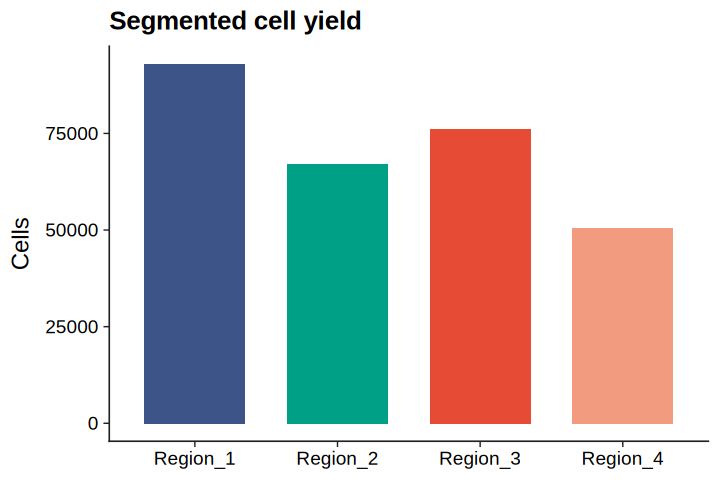

In [38]:
print(slide_plots$cell_yield)

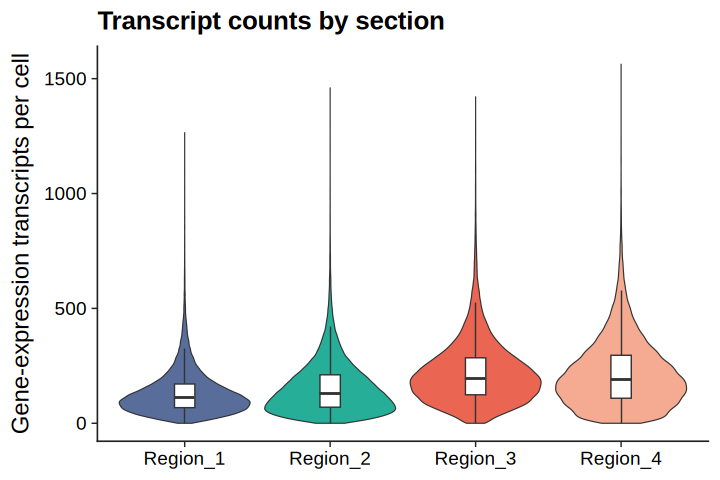

In [39]:
print(slide_plots$counts)

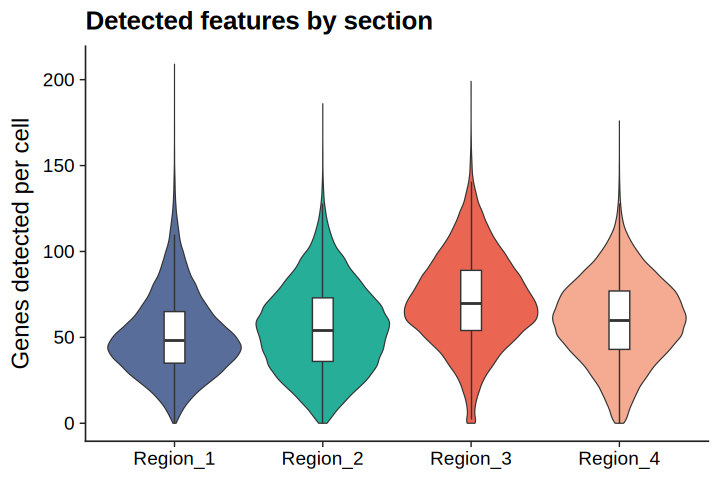

In [40]:
print(slide_plots$features)

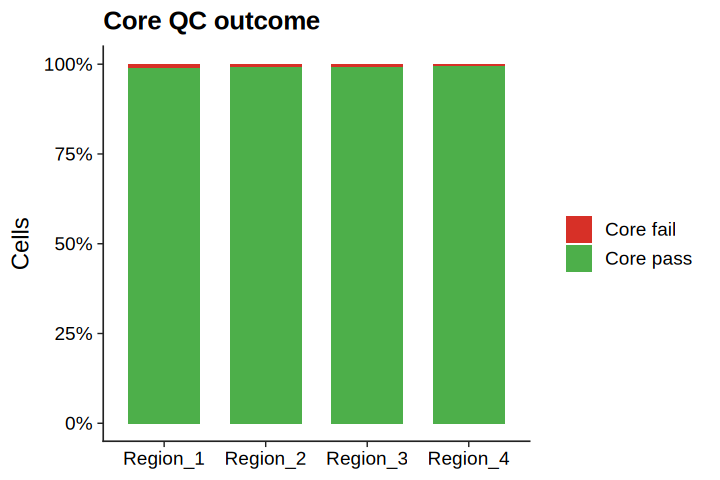

In [41]:
print(slide_plots$review)

In [47]:
options(repr.plot.width=11, repr.plot.height=5)

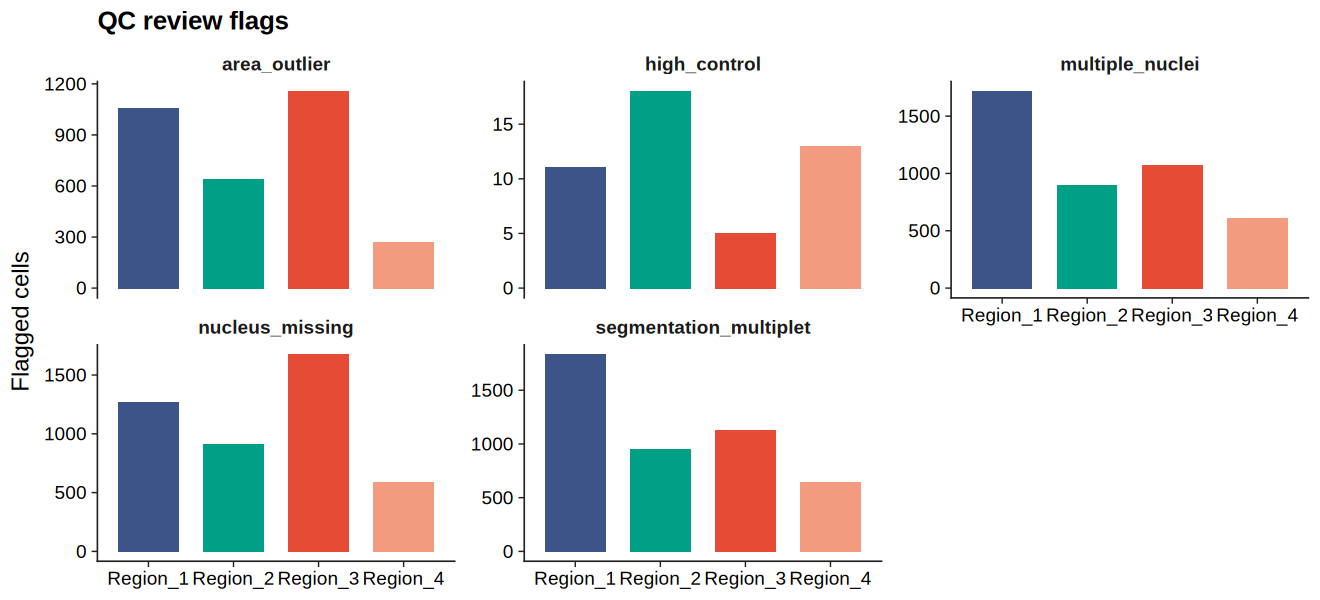

In [48]:
print(slide_plots$flags)

In [53]:
options(repr.plot.width=8, repr.plot.height=5)

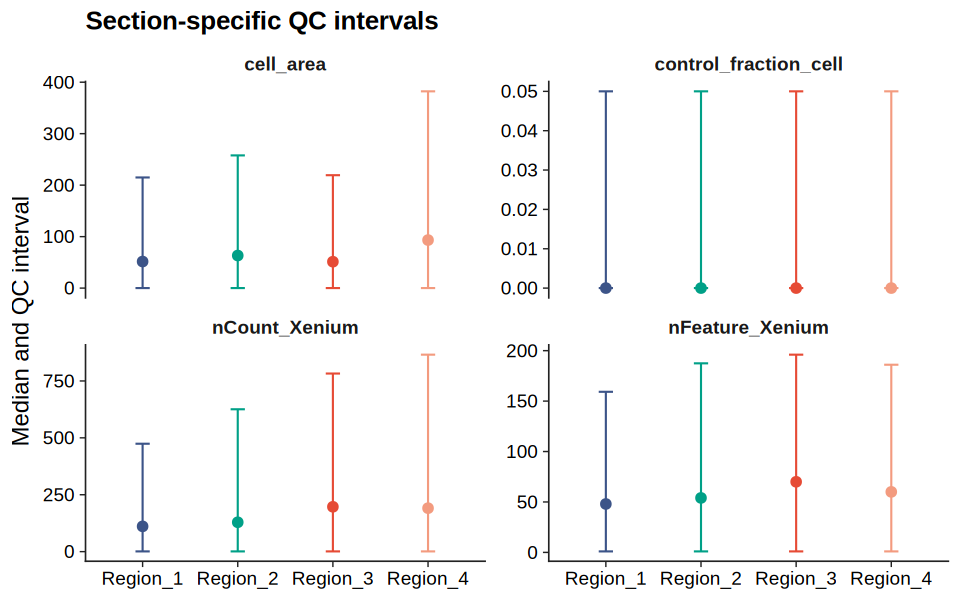

In [54]:
print(slide_plots$thresholds)

## Step3 - Alarm evidence and evidence-only gene tiers

In [55]:
extended_slide_data$cycle_alarm_evidence

region_id,raised,title,message,level,id,evidence_status,cycle_identity_status,gene_effect_status
<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Region_1,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected,DIRECT_EVIDENCE,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,GENE_EFFECT_UNCONFIRMED
Region_2,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected,DIRECT_EVIDENCE,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,GENE_EFFECT_UNCONFIRMED
Region_3,FALSE,NA,NA,NA,NA,NO_ALARM_REPORTED,NO_POOR_CYCLE_ALARM_REPORTED,NO_POOR_CYCLE_ALARM_REPORTED
Region_4,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected,DIRECT_EVIDENCE,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,GENE_EFFECT_UNCONFIRMED


Gene QCed by 
- abundance_depletion
- quality_degradation

and flagged as
- CONSERVATIVE_NO_SIGNAL_DETECTED: 0 alarm-positive regions
- PROVISIONAL_PRIMARY_FEATURES: alarms ≤ 1
- TECHNICAL_RISK_SENSITIVITY_ONLY: alarms ≥ 2

In [56]:
gene_tier_counts <- data.frame(
  decision = c("RAW_COMPLETE_PANEL", "CONSERVATIVE_NO_SIGNAL_DETECTED", "PROVISIONAL_PRIMARY_FEATURES", "TECHNICAL_RISK_SENSITIVITY_ONLY"),
  genes = c(nrow(evidence_summary$genes), sum(evidence_summary$genes$conservative_evidence_status == "CONSERVATIVE_NO_SIGNAL_DETECTED"), sum(evidence_summary$genes$primary_feature_status == "PROVISIONAL_PRIMARY_FEATURES"), sum(evidence_summary$genes$technical_risk_status == "TECHNICAL_RISK_SENSITIVITY_ONLY"))
)

In [57]:
gene_tier_counts

decision,genes
<chr>,<int>
RAW_COMPLETE_PANEL,479
CONSERVATIVE_NO_SIGNAL_DETECTED,67
PROVISIONAL_PRIMARY_FEATURES,245
TECHNICAL_RISK_SENSITIVITY_ONLY,234


In [64]:
with(evidence_summary$eos[evidence_summary$eos$retained_provisional, ], table(gene_set))

gene_set
     common  long_lived short_lived 
          4          22          27 

## Step 4 - Subset versus full-data burden

In [65]:
extended_slide_summary$ranking

,region_id,review_fraction,subset_rank,input_cells,review_flagged,full_review_fraction,full_rank,rank_change,review_fraction_difference,comparison_status
,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>
1,Region_1,0.074,1,92911,4664,0.05019858,2,1,-0.023801423,FULL_DATA_COMPARISON
2,Region_2,0.032,3,66980,2703,0.04035533,3,0,0.008355330,FULL_DATA_COMPARISON
3,Region_3,0.054,2,75957,4268,0.05618969,1,-1,0.002189686,FULL_DATA_COMPARISON
4,Region_4,0.022,4,50330,1622,0.03222730,4,0,0.010227300,FULL_DATA_COMPARISON


In [66]:
extended_slide_summary$rank_agreement

sections,spearman_rho,kendall_tau,interpretation,comparison_status
<int>,<dbl>,<dbl>,<chr>,<chr>
4,0.8,0.6666667,DESCRIPTIVE_FOUR_SECTIONS,FULL_DATA_COMPARISON


## Step5 - Spatial QC

In [67]:
extended_slide_data$spatial_global

status,statistic,empirical_p,permutations,k,seed,region_id,diagnostic_type
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
ESTIMATED,0.02282610,0.001,999,15,20260814,Region_1,global_clustering
ESTIMATED,0.02144443,0.001,999,15,20260814,Region_2,global_clustering
ESTIMATED,0.04959762,0.001,999,15,20260814,Region_3,global_clustering
ESTIMATED,0.01965822,0.001,999,15,20260814,Region_4,global_clustering


In [68]:
extended_slide_data$spatial_edge_density

class_type,class,cells,flagged,review_rate,risk_ratio,absolute_rate_difference,region_id,diagnostic_type
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
edge_proxy,edge,6886,498,0.07232065,1.4944914,0.023892868,Region_1,edge_density_enrichment
edge_proxy,interior,86025,4166,0.04842778,1.4944914,0.023892868,Region_1,edge_density_enrichment
local_density,dense,9292,191,0.02055532,0.3851905,-0.032937311,Region_1,edge_density_enrichment
local_density,non_dense,83619,4473,0.05349263,0.3851905,-0.032937311,Region_1,edge_density_enrichment
edge_proxy,edge,4272,227,0.05313670,1.3481557,0.013652109,Region_2,edge_density_enrichment
edge_proxy,interior,62708,2476,0.03948460,1.3481557,0.013652109,Region_2,edge_density_enrichment
local_density,dense,6698,127,0.01896088,0.4453125,-0.023771607,Region_2,edge_density_enrichment
local_density,non_dense,60282,2576,0.04273249,0.4453125,-0.023771607,Region_2,edge_density_enrichment
edge_proxy,edge,4603,265,0.05757115,1.0278122,0.001470580,Region_3,edge_density_enrichment


In [70]:
head(evidence_summary$hotspots, n=2)

,grid_id,cells,flagged,review_rate,global_rate,rate_difference,empirical_p,adjusted_p,hotspot_status,x_min,⋯,hotspot_cells_from_mask,primary_handling,sensitivity_handling,morphology_status,decision_rule,run_label,execution_mode,generated_utc,source_artifact,provenance
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2885,2:33,56,15,0.2678571,0.05618969,0.2116675,0.001,0.03932353,MORPHOLOGY_REVIEW_REQUIRED,202.1595,⋯,56,KEEP_IN_PRIMARY,EXCLUDE_IN_HOTSPOT_SENSITIVITY,NOT_CONFIRMED_AS_ARTIFACT,FDR-positive Region_3 bins are retained in primary and excluded only in hotspot sensitivity,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,slide_summary/combined_spatial_hotspots.tsv,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
2912,14:27,38,9,0.2368421,0.05618969,0.1806524,0.001,0.03932353,MORPHOLOGY_REVIEW_REQUIRED,1407.1262,⋯,38,KEEP_IN_PRIMARY,EXCLUDE_IN_HOTSPOT_SENSITIVITY,NOT_CONFIRMED_AS_ARTIFACT,FDR-positive Region_3 bins are retained in primary and excluded only in hotspot sensitivity,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,slide_summary/combined_spatial_hotspots.tsv,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2


## Step6 - Within-mouse concordance

In [71]:
extended_slide_summary$concordance$summary

mouse_id,section_a,section_b,region_a,region_b,pair_status,review_rate_a,review_rate_b,review_rate_difference,median_count_ratio,⋯,control_quantile_distance,gene_count_spearman,gene_detection_spearman,review_criterion,count_criterion,feature_criterion,gene_count_criterion,gene_detection_criterion,concordance_status,interpretation
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>
Mouse_1,62308,62309,Region_1,Region_2,ESTIMABLE,0.05019858,0.04035533,0.009843247,1.1621622,⋯,0.0000922958,0.9361446,0.9343017,TRUE,TRUE,TRUE,TRUE,TRUE,CONCORDANT,ADVISORY_TECHNICAL_CONCORDANCE_NOT_BIOLOGICAL_TEST
Mouse_2,62310,62311,Region_3,Region_4,ESTIMABLE,0.05618969,0.03222730,0.023962386,0.9695431,⋯,0.0002346235,0.9298257,0.9277999,TRUE,TRUE,TRUE,TRUE,TRUE,CONCORDANT,ADVISORY_TECHNICAL_CONCORDANCE_NOT_BIOLOGICAL_TEST


## Step7 - Diagnostic Cell-style figures

In [106]:
extended_slide_plots <- plot_extended_slide_qc(extended_slide_data, extended_slide_summary)

In [73]:
names(extended_slide_plots)

[1] "alarm_evidence"  "candidate_genes" "ranking"         "spatial"        
[5] "concordance"

In [74]:
options(repr.plot.width=6, repr.plot.height=4)

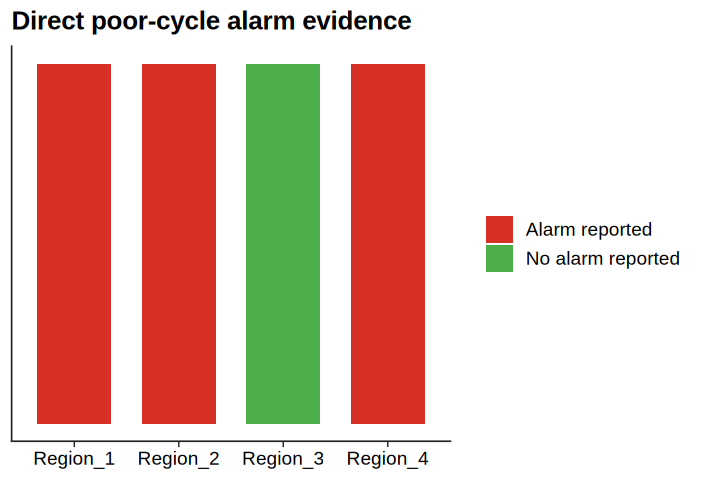

In [75]:
print(extended_slide_plots$alarm_evidence)

In [83]:
options(repr.plot.width=6.5, repr.plot.height=4)

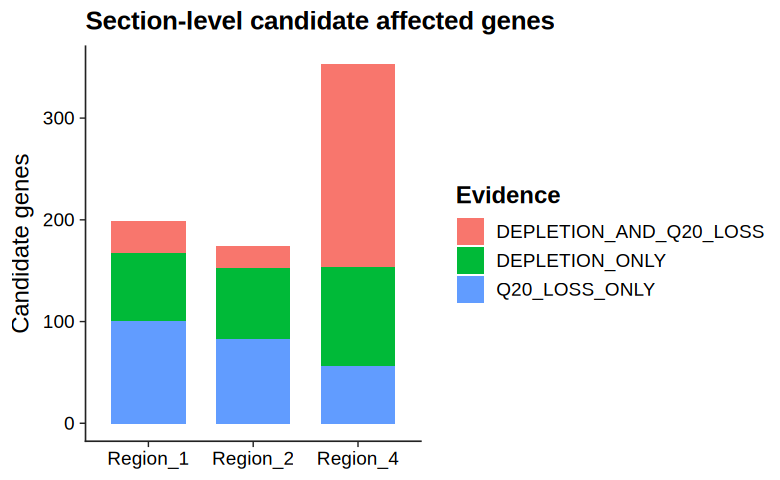

In [84]:
print(extended_slide_plots$candidate_genes)

In [85]:
options(repr.plot.width=6, repr.plot.height=4)

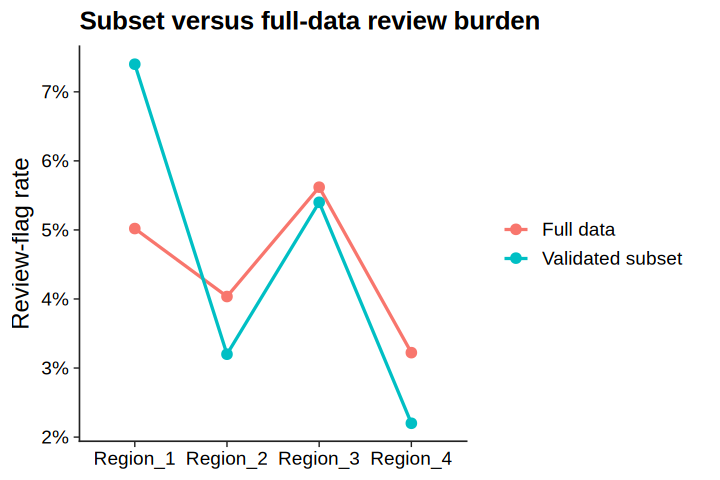

In [86]:
print(extended_slide_plots$ranking)

In [102]:
options(repr.plot.width=5.3, repr.plot.height=4)

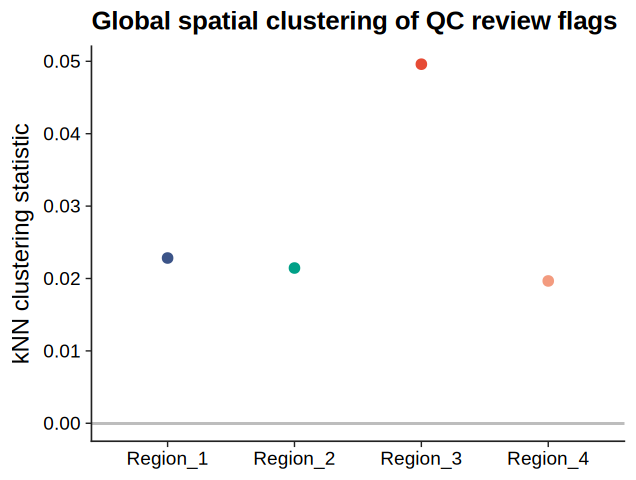

In [103]:
print(extended_slide_plots$spatial)

In [ ]:
options(repr.plot.width=6, repr.plot.height=4)

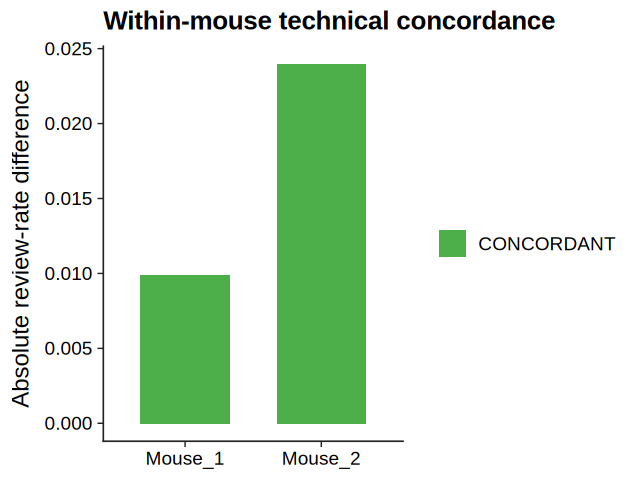

In [107]:
print(extended_slide_plots$concordance)

In [108]:
mask_plot_data <- evidence_summary$sections[, c("region_id", "primary_include_cells", "strict_include_cells", "hotspot_sensitivity_include_cells")]
mask_long <- reshape(mask_plot_data, varying = names(mask_plot_data)[-1], v.names = "cells", timevar = "mask", times = names(mask_plot_data)[-1], direction = "long")

In [114]:
options(repr.plot.width=8, repr.plot.height=4)

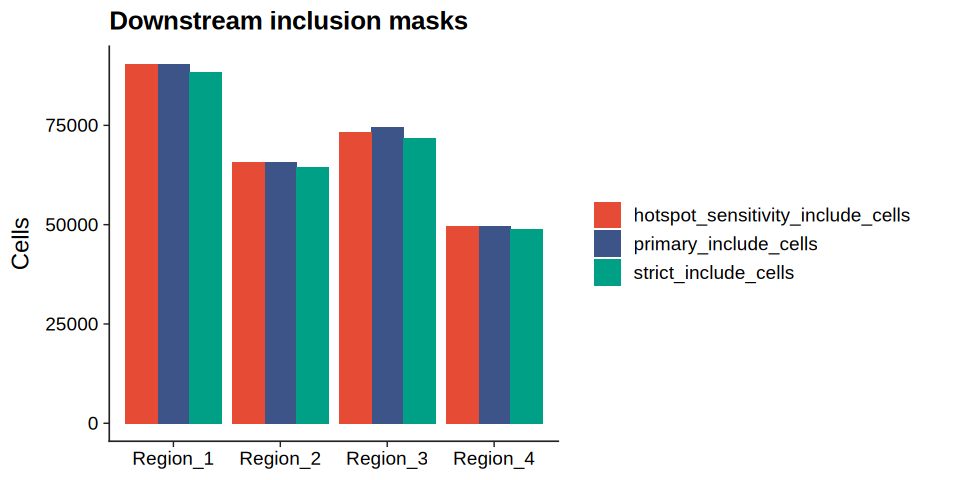

In [115]:
print(ggplot2::ggplot(mask_long, ggplot2::aes(region_id, cells, fill = mask)) + ggplot2::geom_col(position = "dodge") + ggplot2::scale_fill_manual(values = c(primary_include_cells="#3C5488", strict_include_cells="#00A087", hotspot_sensitivity_include_cells="#E64B35")) + ggplot2::labs(title="Downstream inclusion masks", x=NULL, y="Cells", fill=NULL) + cell_style_theme())

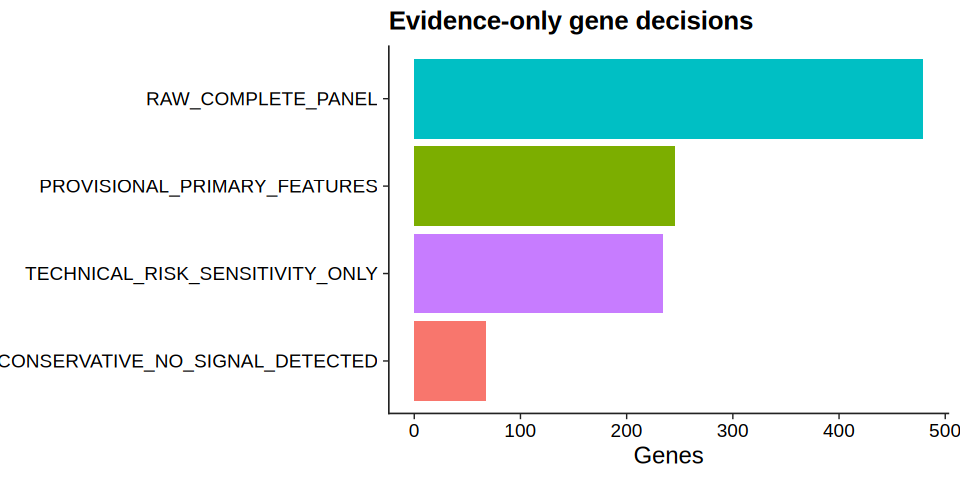

In [116]:
print(ggplot2::ggplot(gene_tier_counts, ggplot2::aes(reorder(decision, genes), genes, fill = decision)) + ggplot2::geom_col(show.legend=FALSE) + ggplot2::coord_flip() + ggplot2::labs(title="Evidence-only gene decisions", x=NULL, y="Genes") + cell_style_theme())

## Step8 - Final QC decision and next actions

In [117]:
evidence_summary$release
cat("Evidence-only primary release:", evidence_summary$release$gate_status[evidence_summary$release$gate_id == "overall_primary_release"], "\n")

gate_id,scope,gate_status,measured_value,threshold,evidence_source,interpretation,next_required_artifact,run_label,execution_mode,generated_utc,source_artifact,provenance
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
fixed_section_decisions,sections,PASS,Region_1=PRIMARY_CONDITIONAL;Region_2=PRIMARY_CONDITIONAL;Region_3=PRIMARY;Region_4=SENSITIVITY_ONLY,R1/R2 conditional; R3 primary; R4 sensitivity-only,section_downstream_decision.tsv,Fixed approved decisions,none,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
cell_mask_reconciliation,cells,PASS,primary=279963;strict=272921;hotspot_sensitivity=278912;total=286178,strict and hotspot masks must be subsets of primary,cell_downstream_masks.tsv.gz,Non-destructive masks reconcile,none,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
gene_tier_reconciliation,genes,PASS,raw=479;conservative=67;provisional=245;risk=234,FULL_HPC: 479/67/245/234,gene_downstream_decision.tsv,Local subset cannot freeze full-data counts,none,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
eos_gene_reconciliation,Eos genes,PASS,retained=53;common=4;short_lived=27;long_lived=22,FULL_HPC: 53=4/27/22,eos_gene_decision_summary.tsv,Local subset cannot freeze full-data Eos retention,none,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
region4_excluded_from_reference_definition,Region_4,PASS,cluster_discovery_eligible=FALSE,FALSE,section_downstream_decision.tsv,Region_4 is mapping-only,Region_1-3 reference,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
section_identity_dominance,PCA/clustering,PENDING_DOWNSTREAM_ANALYSIS,NA,section identity must not dominate,downstream PCA and cluster diagnostics,Primary release cannot pass until downstream evidence is supplied,PCA section-mixing diagnostics,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
primary_strict_celltype_stability,major cell types,PENDING_DOWNSTREAM_ANALYSIS,NA,stable assignments,primary/strict label comparison,Primary release cannot pass until downstream evidence is supplied,cell-type stability table,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
feature245_vs_gene67_celltype_agreement,major cell types,PENDING_DOWNSTREAM_ANALYSIS,NA,no contradictory major cell types,245/67 sensitivity comparison,Primary release cannot pass until downstream evidence is supplied,245-vs-67 comparison,full_notebook_qc_v2,FULL_HPC,2026-08-18 08:08:40 UTC,evidence-only QC decision engine,full_notebook_qc_v2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_q

Evidence-only primary release: PENDING_DOWNSTREAM_ANALYSIS 


## Outputs and reload checks

Required outputs are `cell_downstream_masks.tsv.gz`, `section_downstream_decision.tsv`, `gene_downstream_decision.tsv`, `eos_gene_decision_summary.tsv`, `hotspot_sensitivity_decision.tsv`, and `evidence_only_qc_release.tsv`. Final raw-count bundles and `downstream_input_manifest.tsv` are written below `${RUN_ROOT}/downstream_inputs/`.

In [12]:
slide_artifacts <- write_slide_qc_artifacts(PROJECT_ROOT, RUN_ROOT, slide_data, slide_summary, slide_plots)
extended_slide_artifacts <- write_extended_slide_qc_artifacts(PROJECT_ROOT, RUN_ROOT, extended_slide_data, extended_slide_summary, extended_slide_plots)
saved_summary <- readRDS(file.path(RUN_ROOT, "slide_summary", "slide_qc_summary.rds"))
stopifnot(nrow(saved_summary$data$coverage) == 4L)
stopifnot(length(unique(saved_summary$data$cell_metadata$region_id)) == 4L)
stopifnot(validate_extended_slide_qc_artifacts(RUN_ROOT, stop_on_error = TRUE))
evidence_only_artifacts <- write_evidence_only_qc_artifacts(PROJECT_ROOT, RUN_ROOT, evidence_summary)
stopifnot(validate_evidence_only_qc_artifacts(RUN_ROOT, stop_on_error = TRUE))
list(core = data.frame(artifact = basename(slide_artifacts), path = slide_artifacts),
     extended = data.frame(artifact = basename(extended_slide_artifacts), path = extended_slide_artifacts),
     evidence_only = data.frame(artifact = basename(evidence_only_artifacts), path = evidence_only_artifacts))


artifact,path
<chr>,<chr>
combined_qc_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/combined_qc_summary.tsv
combined_qc_thresholds.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/combined_qc_thresholds.tsv
combined_readiness.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/combined_readiness.tsv
combined_analysis_alerts.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/combined_analysis_alerts.tsv
combined_cell_qc_metadata.tsv.gz,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/combined_cell_qc_metadata.tsv.gz
slide_qc_summary.rds,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/slide_qc_summary.rds
scwat_slide_qc_figures.pdf,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/figures/scwat_slide_qc_figures.pdf
slide_cell_yield.png,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/figures/slide_cell_yield.png
slide_counts.png,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/slide_summary/figures/slide_counts.png
